In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

path_jan = "../data/2020-Jan.csv"
path_feb = "../data/2020-Feb.csv"

jan = pd.read_csv(path_jan)
feb = pd.read_csv(path_feb)

print(f"Yanvar: {jan.shape[0]:,} sətir, {jan.shape[1]} sütun")
print(f"Fevral: {feb.shape[0]:,} sətir, {feb.shape[1]} sütun")

df = pd.concat([jan, feb], ignore_index=True)
df['event_time'] = pd.to_datetime(df['event_time'])

print(f"\nBirləşdirilmiş dataset: {df.shape[0]:,} sətir")
print(f"Tarix aralığı: {df['event_time'].min()} -> {df['event_time'].max()}")

Yanvar: 4,264,752 sətir, 9 sütun
Fevral: 4,156,682 sətir, 9 sütun

Birləşdirilmiş dataset: 8,421,434 sətir
Tarix aralığı: 2020-01-01 00:00:00+00:00 -> 2020-02-29 23:59:59+00:00


In [7]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-01-01 00:00:00+00:00,view,5809910,1602943681873052386,NaN,grattol,5.24,595414620,4adb70bb-edbd-4981-b60f-a05bfd32683a
1,2020-01-01 00:00:09+00:00,view,5812943,1487580012121948301,NaN,kinetics,3.97,595414640,c8c5205d-be43-4f1d-aa56-4828b8151c8a
2,2020-01-01 00:00:19+00:00,view,5798924,1783999068867920626,NaN,zinger,3.97,595412617,46a5010f-bd69-4fbe-a00d-bb17aa7b46f3
3,2020-01-01 00:00:24+00:00,view,5793052,1487580005754995573,NaN,NaN,4.92,420652863,546f6af3-a517-4752-a98b-80c4c5860711
4,2020-01-01 00:00:25+00:00,view,5899926,2115334439910245200,NaN,NaN,3.92,484071203,cff70ddf-529e-4b0c-a4fc-f43a749c0acb


In [8]:
event_dist = df['event_type'].value_counts()
event_pct = (df['event_type'].value_counts(normalize=True) * 100).round(2)
event_summary = pd.DataFrame({'Count': event_dist, 'Pct': event_pct})
event_summary


,Count,Pct
event_type,,
view,3991194,47.39
cart,2297017,27.28
remove_from_cart,1627433,19.32
purchase,505790,6.01


In [10]:
viewed_users = set(df[df['event_type'] == 'view']['user_id'])
cart_users = set(df[df['event_type'] == 'cart']['user_id'])
purchase_users = set(df[df['event_type'] == 'purchase']['user_id'])
funnel_counts = {
    'View': len(viewed_users),
    'Cart': len(cart_users),
    'Purchase': len(purchase_users)
}
for stage, count in funnel_counts.items():
    print(f"{stage}: {count:,} unikal istifadəçi")

View: 716,987 unikal istifadəçi
Cart: 162,035 unikal istifadəçi
Purchase: 49,473 unikal istifadəçi


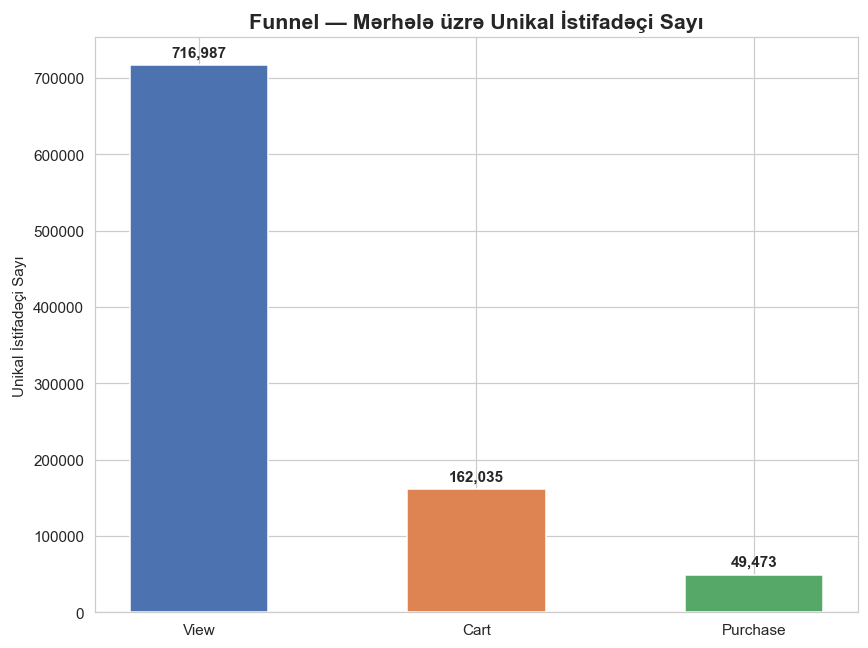

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
stages = list(funnel_counts.keys())
values = list(funnel_counts.values())
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(stages, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(values)*0.01, f'{val:,}',
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Funnel — Mərhələ üzrə Unikal İstifadəçi Sayı', fontsize=14, fontweight='bold')
ax.set_ylabel('Unikal İstifadəçi Sayı')
plt.tight_layout()
plt.savefig('funnel_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
view_to_cart = len(cart_users & viewed_users) / len(viewed_users) * 100
cart_to_purchase = len(purchase_users & cart_users) / len(cart_users) * 100
view_to_purchase = len(purchase_users & viewed_users) / len(viewed_users) * 100
print(f"View -> Cart rate:          {view_to_cart:.2f}%")
print(f"Cart -> Purchase rate:      {cart_to_purchase:.2f}%")
print(f"View -> Purchase (overall): {view_to_purchase:.2f}%")

View -> Cart rate:          19.94%
Cart -> Purchase rate:      30.21%
View -> Purchase (overall): 6.54%


In [13]:
views_only = df[df['event_type'] == 'view']
top8_categories = views_only['category_code'].value_counts().head(8).index.tolist()
print("Top 8 kateqoriya (baxış sayına görə):")
for cat in top8_categories:
    print(f"  - {cat}")

Top 8 kateqoriya (baxış sayına görə):
  - appliances.environment.vacuum
  - furniture.living_room.cabinet
  - apparel.glove
  - stationery.cartrige
  - accessories.bag
  - furniture.bathroom.bath
  - appliances.personal.massager
  - appliances.personal.hair_cutter


In [14]:
category_results = []
for cat in top8_categories:
    cat_df = df[df['category_code'] == cat]
    v = set(cat_df[cat_df['event_type'] == 'view']['user_id'])
    c = set(cat_df[cat_df['event_type'] == 'cart']['user_id'])
    p = set(cat_df[cat_df['event_type'] == 'purchase']['user_id'])
    v2c = len(c & v) / len(v) * 100 if v else 0
    c2p = len(p & c) / len(c) * 100 if c else 0
    v2p = len(p & v) / len(v) * 100 if v else 0
    category_results.append([cat, len(v), len(c), len(p), round(v2c, 2), round(c2p, 2), round(v2p, 2)])

category_funnel = pd.DataFrame(
    category_results,
    columns=['category_code', 'View_Users', 'Cart_Users', 'Purchase_Users',
             'View2Cart_%', 'Cart2Purchase_%', 'View2Purchase_%']
).sort_values('View2Purchase_%', ascending=False)
category_funnel


,category_code,View_Users,Cart_Users,Purchase_Users,View2Cart_%,Cart2Purchase_%,View2Purchase_%
2,apparel.glove,4965,4128,1932,38.13,43.41,18.43
3,stationery.cartrige,4313,2265,1025,21.89,42.38,9.90
0,appliances.environment.vacuum,15431,3883,1366,18.69,32.29,6.86
5,furniture.bathroom.bath,3602,1164,384,17.93,30.67,6.55
6,appliances.personal.massager,1335,151,35,9.06,23.18,2.32
7,appliances.personal.hair_cutter,1141,113,28,6.92,23.01,2.02
1,furniture.living_room.cabinet,5377,760,119,10.01,14.34,1.82
4,accessories.bag,3147,146,45,3.88,30.14,1.21


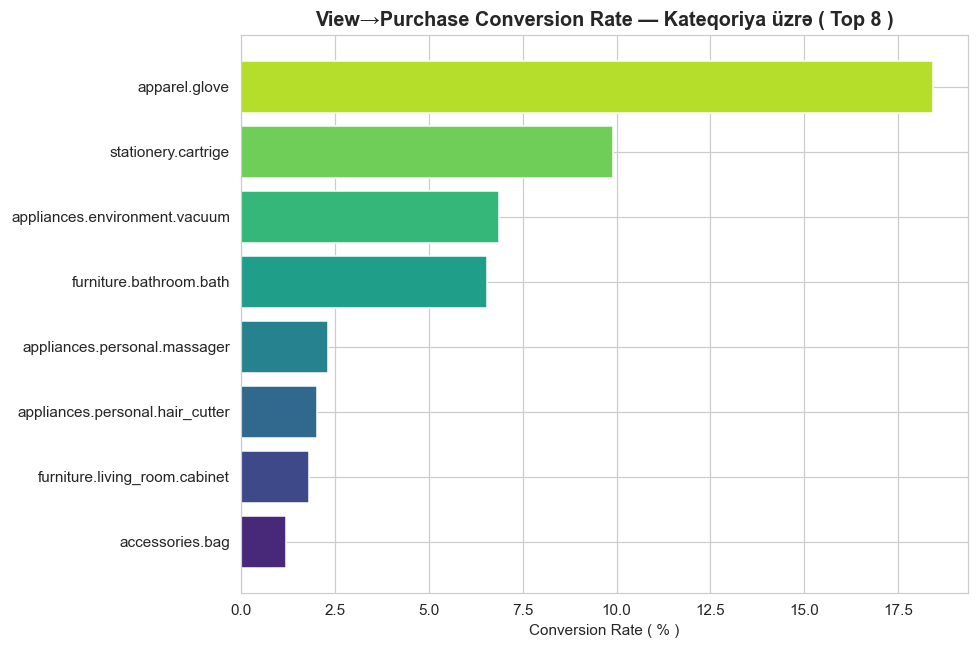

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
cat_sorted = category_funnel.sort_values('View2Purchase_%', ascending=True)
colors = sns.color_palette('viridis', len(cat_sorted))
ax.barh(cat_sorted['category_code'], cat_sorted['View2Purchase_%'], color=colors)
ax.set_title('View→Purchase Conversion Rate — Kateqoriya üzrə ( Top 8 )', fontsize=13, fontweight='bold')
ax.set_xlabel('Conversion Rate ( % )')
plt.tight_layout()
plt.savefig('conversion_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
def compute_funnel(data):
    v = set(data[data['event_type'] == 'view']['user_id'])
    c = set(data[data['event_type'] == 'cart']['user_id'])
    p = set(data[data['event_type'] == 'purchase']['user_id'])
    return {
        'View_Users': len(v), 'Cart_Users': len(c), 'Purchase_Users': len(p),
        'View2Cart_%': round(len(c & v) / len(v) * 100, 2),
        'Cart2Purchase_%': round(len(p & c) / len(c) * 100, 2),
        'View2Purchase_%': round(len(p & v) / len(v) * 100, 2)
    }
jan_funnel = compute_funnel(jan)
feb_funnel = compute_funnel(feb)
monthly_comparison = pd.DataFrame({'January': jan_funnel, 'February': feb_funnel})
monthly_comparison['Change'] = (monthly_comparison['February'] - monthly_comparison['January']).round(2)
monthly_comparison

,January,February,Change
View_Users,397775.00,379246.00,-18529.00
Cart_Users,92653.00,89269.00,-3384.00
Purchase_Users,28220.00,25759.00,-2461.00
View2Cart_%,20.41,20.65,0.24
Cart2Purchase_%,30.08,28.41,-1.67
View2Purchase_%,6.65,6.38,-0.27


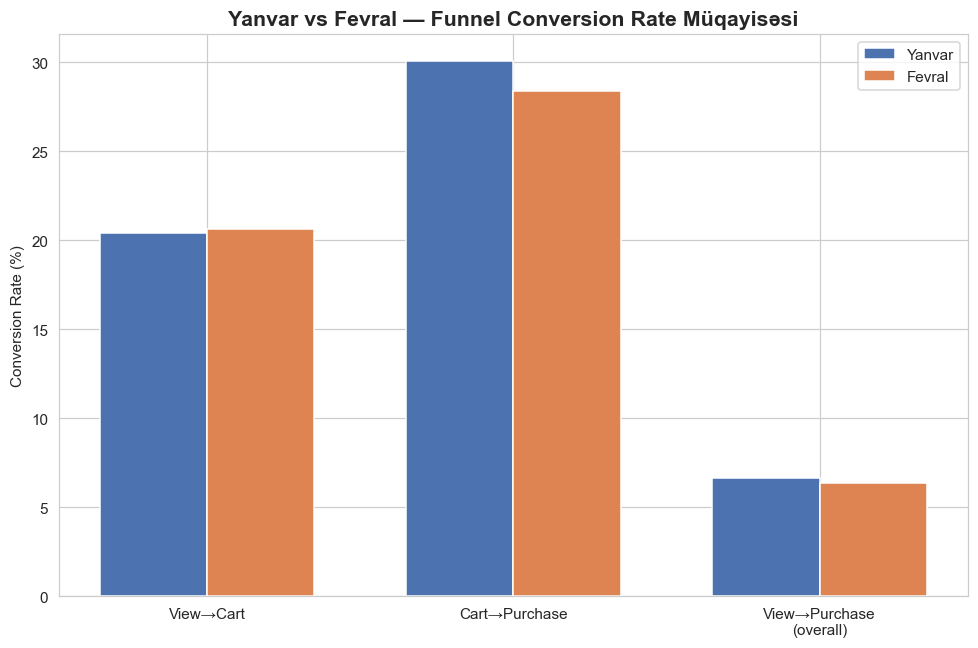

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(3)
width = 0.35
metrics = ['View2Cart_%', 'Cart2Purchase_%', 'View2Purchase_%']
metric_labels = ['View→Cart', 'Cart→Purchase', 'View→Purchase\n(overall)']
jan_vals = [jan_funnel[m] for m in metrics]
feb_vals = [feb_funnel[m] for m in metrics]
ax.bar(x - width/2, jan_vals, width, label='Yanvar', color='#4C72B0', edgecolor='white')
ax.bar(x + width/2, feb_vals, width, label='Fevral', color='#DD8452', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Yanvar vs Fevral — Funnel Conversion Rate Müqayisəsi', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('jan_vs_feb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
purchases = df[df['event_type'] == 'purchase']
top10_brands = purchases['brand'].value_counts().head(10)
total_purchases = len(purchases)
top10_share = top10_brands.sum() / total_purchases * 100
print(f"Top 10 brand-ın ümumi alışlardakı payı: {top10_share:.2f}%")
brand_results = []
for brand in top10_brands.index:
    b_df = df[df['brand'] == brand]
    v = set(b_df[b_df['event_type'] == 'view']['user_id'])
    p = set(b_df[b_df['event_type'] == 'purchase']['user_id'])
    rate = len(p & v) / len(v) * 100 if v else 0
    brand_results.append([brand, top10_brands[brand], len(v), round(rate, 2)])
brand_funnel = pd.DataFrame(
    brand_results, columns=['Brand', 'Purchase_Count', 'View_Users', 'View2Purchase_%']
)
brand_funnel


Top 10 brand-ın ümumi alışlardakı payı: 32.63%


,Brand,Purchase_Count,View_Users,View2Purchase_%
0,runail,45274,86823,12.87
1,irisk,31210,70510,12.51
2,grattol,21320,48870,11.64
3,masura,19929,35640,10.97
4,ingarden,10276,23716,13.39
5,estel,8616,40234,7.28
6,bpw.style,8437,13376,14.60
7,uno,6871,22313,9.99
8,italwax,6740,19923,9.18
9,kapous,6370,42289,4.86


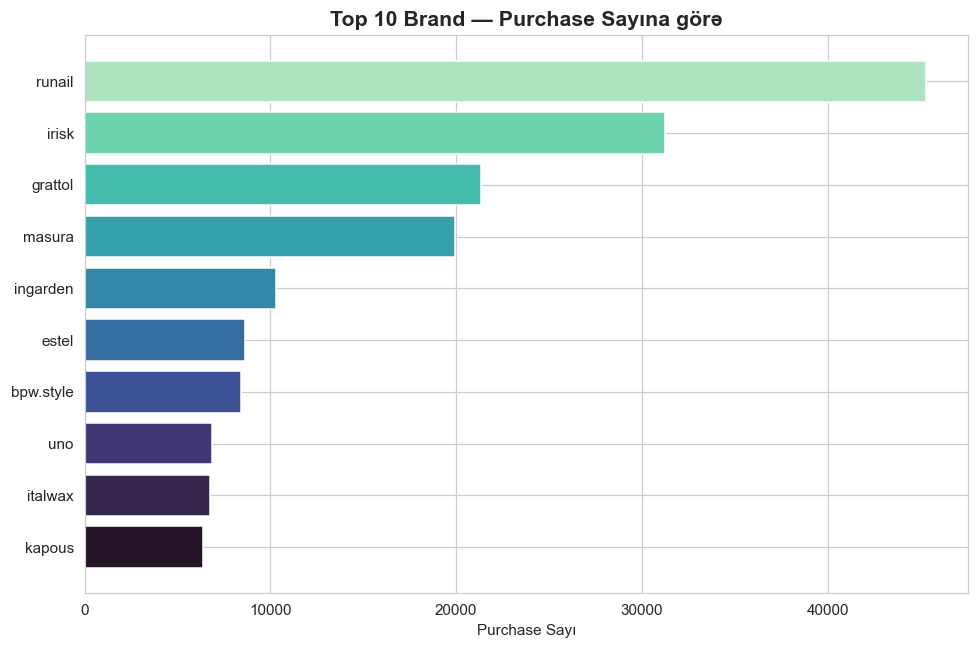

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
brand_sorted = brand_funnel.sort_values('Purchase_Count', ascending=True)
colors = sns.color_palette('mako', len(brand_sorted))
ax.barh(brand_sorted['Brand'], brand_sorted['Purchase_Count'], color=colors)
ax.set_title('Top 10 Brand — Purchase Sayına görə', fontsize=14, fontweight='bold')
ax.set_xlabel('Purchase Sayı')
plt.tight_layout()
plt.savefig('top10_brands.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
purchase_prices = purchases['price']
Q1 = purchase_prices.quantile(0.25)
Q3 = purchase_prices.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = purchases[(purchases['price'] < lower_bound) | (purchases['price'] > upper_bound)]
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Normal aralıq: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outlier sayı: {len(outliers):,} ({len(outliers)/len(purchases)*100:.2f}% bütün alışlardan)")
print(f"Maksimum qiymət: ${purchase_prices.max():.2f}")
print(f"Orta qiymət: ${purchase_prices.mean():.2f}")
negative_prices = (purchase_prices < 0).sum()
print(f"\nMənfi qiymətli alış sətri ( data keyfiyyəti problemi ): {negative_prices}")


Q1: 1.59, Q3: 5.56, IQR: 3.97
Normal aralıq: [-4.37, 11.52]
Outlier sayı: 34,947 (6.91% bütün alışlardan)
Maksimum qiymət: $327.78
Orta qiymət: $5.00

Mənfi qiymətli alış sətri ( data keyfiyyəti problemi ): 71


In [21]:
converted_users = set(purchases['user_id'])
sub = df[df['user_id'].isin(converted_users) & df['event_type'].isin(['view', 'purchase'])]
first_view = sub[sub['event_type'] == 'view'].groupby('user_id')['event_time'].min()
first_purchase = sub[sub['event_type'] == 'purchase'].groupby('user_id')['event_time'].min()
time_to_purchase = pd.DataFrame({'first_view': first_view, 'first_purchase': first_purchase}).dropna()
time_to_purchase['hours'] = (time_to_purchase['first_purchase'] - time_to_purchase['first_view']).dt.total_seconds() / 3600
time_to_purchase = time_to_purchase[time_to_purchase['hours'] >= 0]
print(f"Convert olan istifadəçi sayı (ilk view/purchase cütü ilə): {len(time_to_purchase):,}")
print(f"Orta müddət: {time_to_purchase['hours'].mean():.2f} saat ({time_to_purchase['hours'].mean()/24:.2f} gün)")
print(f"Median müddət: {time_to_purchase['hours'].median():.2f} saat")


Convert olan istifadəçi sayı (ilk view/purchase cütü ilə): 45,571
Orta müddət: 131.81 saat (5.49 gün)
Median müddət: 4.53 saat


In [22]:
product_stats = df.groupby('product_id').agg(
    views=('event_type', lambda x: (x == 'view').sum()),
    purchases=('event_type', lambda x: (x == 'purchase').sum())
).reset_index()
# statistik etibarlılıq üçün minimum 100 baxış
product_stats = product_stats[product_stats['views'] >= 100]
product_stats['conversion_rate'] = (product_stats['purchases'] / product_stats['views'] * 100).round(3)
view_q75 = product_stats['views'].quantile(0.75)
conv_q25 = product_stats['conversion_rate'].quantile(0.25)
high_view_low_conv = product_stats[
    (product_stats['views'] > view_q75) & (product_stats['conversion_rate'] < conv_q25)
].sort_values('views', ascending=False)

brand_lookup = df.drop_duplicates('product_id')[['product_id', 'brand']]
high_view_low_conv = high_view_low_conv.merge(brand_lookup, on='product_id', how='left')

print(f"Yüksək-view/aşağı-conversion məhsul sayı: {len(high_view_low_conv)} / {len(product_stats)}")
high_view_low_conv[['product_id', 'brand', 'views', 'purchases', 'conversion_rate']].head(10)


Yüksək-view/aşağı-conversion məhsul sayı: 627 / 8333


,product_id,brand,views,purchases,conversion_rate
0,5808664,ardell,17194,23,0.134
1,5917178,NaN,13930,344,2.469
2,5790563,NaN,8081,418,5.173
3,5924482,NaN,7842,214,2.729
4,5877456,jessnail,7800,21,0.269
5,5856186,runail,7761,79,1.018
6,5769877,kapous,7608,66,0.868
7,5850281,marathon,7482,80,1.069
8,5877454,jessnail,7230,82,1.134
9,5649236,concept,7046,240,3.406
